# Legends and colorbars in spatialdata-plot

Every coloured plot needs a key. `spatialdata-plot` builds three kinds automatically: a **categorical** colour (named groups) gets a
**legend**, a **continuous** colour (a numeric range) gets a **colorbar**, and a multichannel image
gets a **channel legend**. `show()` places and styles the legend and colorbar; the channel legend is
switched on with `render_images(channels_as_legend=True)`. By the end you should be able
to:

- Place a categorical legend anywhere (`legend_loc`) and restyle it (`legend_fontsize`,
  `legend_fontweight`, `legend_fontoutline`, `legend_title`), or bundle those in `legend_params`.
- Control which categories appear with `na_in_legend`.
- Place and style a colorbar with `colorbar` / `colorbar_params`.
- Label a multichannel composite with `channels_as_legend`.
- Combine keys across a multi-panel figure.

We use the real 10x **Visium** mouse-brain dataset from `squidpy` for the legend and colorbar, and the
Xenium **`cells`** fluorescence image for the channel legend — both cached on first use.

## Setup

In [1]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sq.datasets.visium_hne_sdata()
sdata

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


INFO     Loading existing dataset from data/spatialdata/visium_hne_sdata.zarr                                      


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/squidpy/datasets/_downloader.py:209: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  return sd.read_zarr(zarr_path)


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## 1. The default categorical legend

Colouring by a categorical column draws a legend automatically. `cluster` holds named brain regions;
we render the spots over the H&E image.

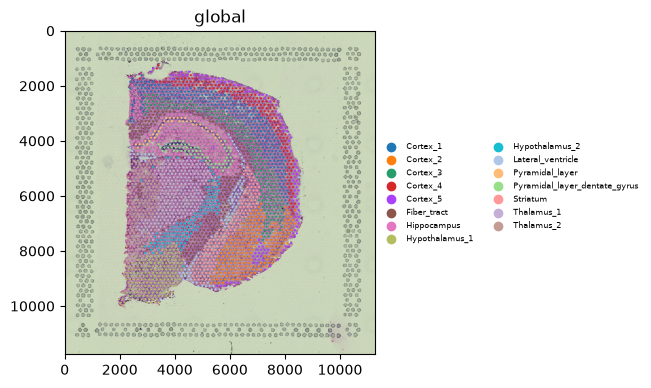

In [2]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
).pl.show(legend_fontsize=6)

## 2. Placing the legend — `legend_loc`

`legend_loc` takes any matplotlib location (`"upper right"`, `"lower left"`, `"center left"`, …) **or**
`"right margin"` to park the legend outside the axes. The margin keeps the legend off the data; the
matplotlib locations place it on top. Here are four placements of the same plot.

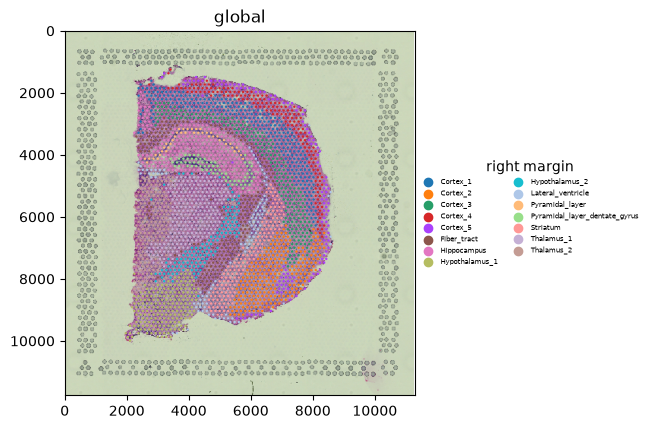

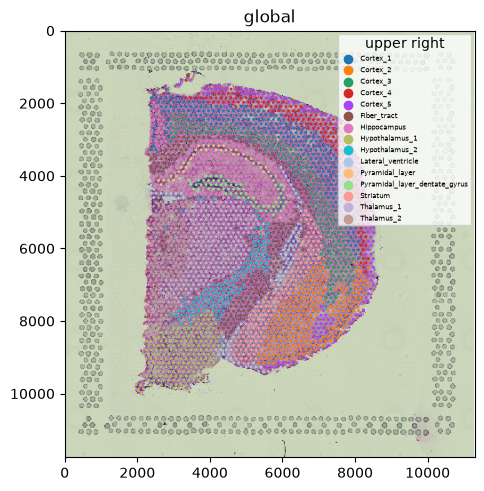

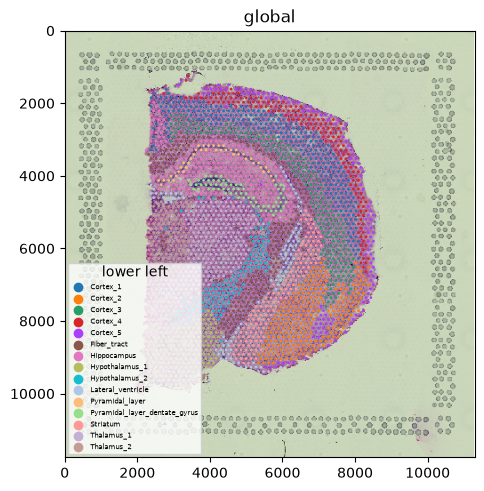

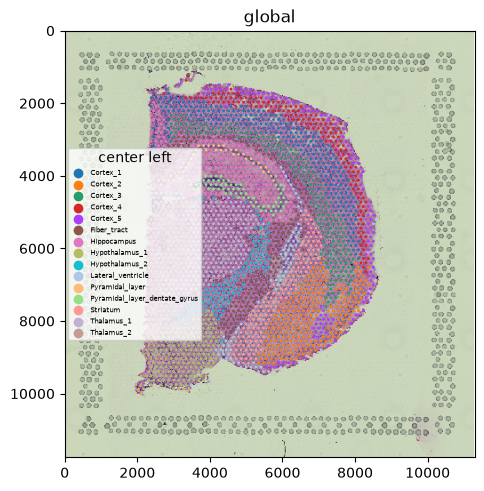

In [3]:
for loc in ["right margin", "upper right", "lower left", "center left"]:
    (
        sdata.pl.render_images("hne")
        .pl.render_shapes("spots", color="cluster")
    ).pl.show(legend_loc=loc, legend_fontsize=5, legend_title=loc)

## 3. Restyling the legend

`legend_fontsize`, `legend_fontweight`, and `legend_fontoutline` (a contrasting outline around the
text, useful over busy images) style the entries; `legend_title` names it.

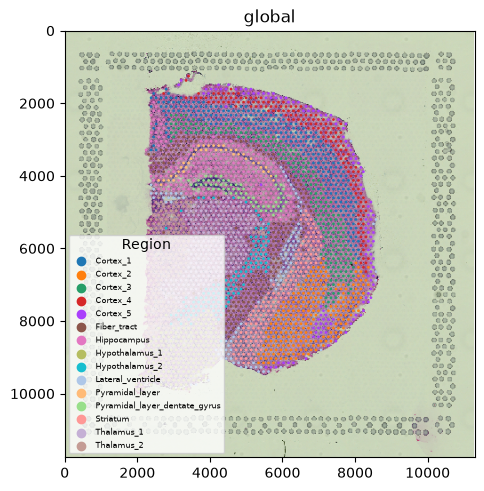

In [4]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
).pl.show(
    legend_loc="lower left",
    legend_fontsize=6,
    legend_fontweight="bold",
    legend_fontoutline=2,
    legend_title="Region",
)

## 4. Hiding NA — `na_in_legend`

`groups` subsets a categorical colour to the named categories; the remaining spots become NA, and
`na_in_legend=False` drops that NA entry from the key.

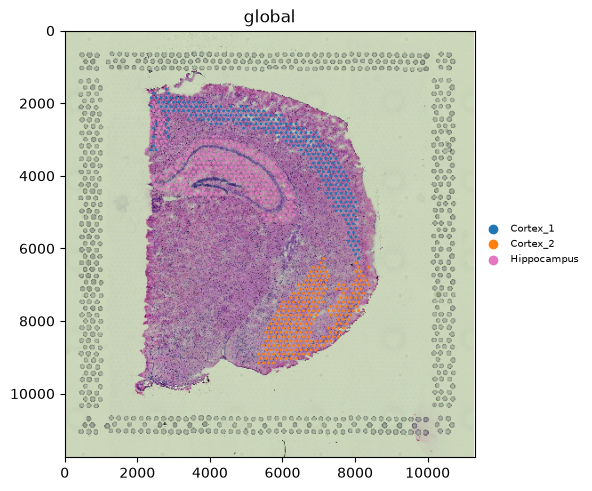

In [5]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster", groups=["Cortex_1", "Cortex_2", "Hippocampus"])
).pl.show(na_in_legend=False, legend_fontsize=7)

## 5. Bundling options — `legend_params`

Instead of the flat `legend_*` kwargs you can pass one `legend_params` dict. Accepted keys:
`location` (or `loc`), `fontsize`, `fontweight`, `fontoutline`, `na_in_legend`; it overrides the
matching flat kwargs, and unknown keys raise an error.

Note `legend_title` is **not** among the accepted keys — keep it as a flat `legend_title=` kwarg.

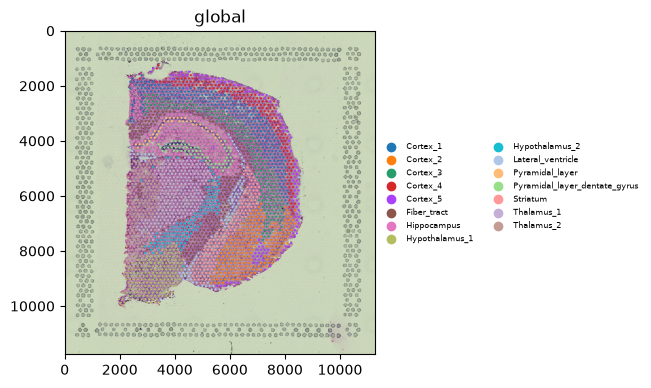

In [6]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
).pl.show(
    legend_params={"loc": "right margin", "fontsize": 6, "fontweight": "bold"},
)

## 6. Continuous colours get a colorbar

Colouring by a continuous column draws a **colorbar** instead of a legend. Here, total counts per
spot. `colorbar=True` is the default; pass `colorbar=False` to suppress it.

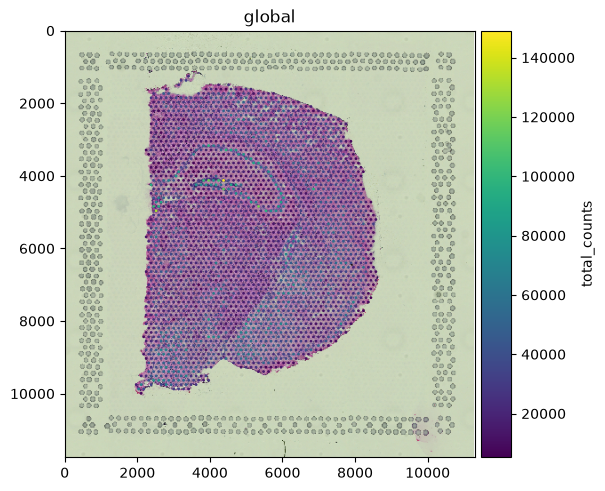

In [7]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="total_counts")
).pl.show()

## 7. Placing and styling the colorbar — `colorbar_params`

`colorbar_params` accepts `label`, `loc` (position — `"right"` by default, or `"left"`/`"top"`/
`"bottom"`), `width` (a fraction of the axes), `pad`, plus matplotlib colorbar keys. Set `loc` to move the bar; its orientation
follows the side automatically (horizontal for top/bottom). Passing only `orientation` does **not**
move it — the bar stays docked right.

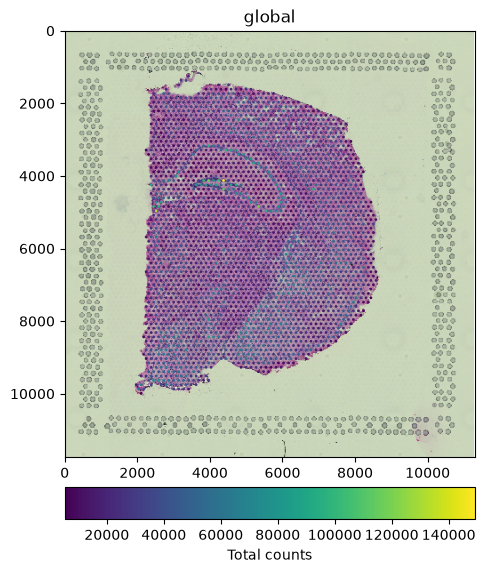

In [8]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="total_counts")
).pl.show(
    colorbar_params={"loc": "bottom", "label": "Total counts"},
)

## 8. Labelling a multichannel image — `channels_as_legend`

A multichannel image has no single colour to key, so `channels_as_legend=True` adds a **channel
legend** mapping each channel to its rendered colour. We switch to the Xenium `cells` fluorescence
image, whose channels are named markers (see the *Multichannel & fluorescence images* tutorial).

INFO     Loading existing dataset from data/spatialdata/cells.zarr                                                 


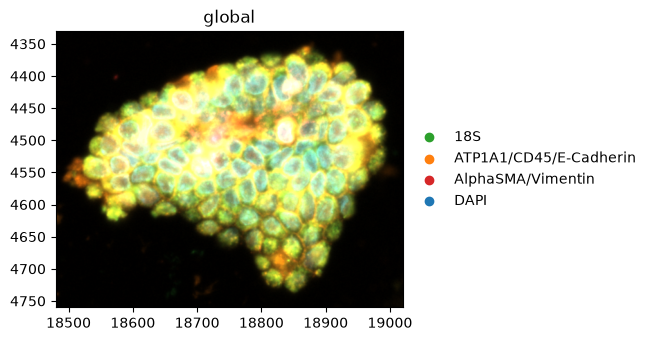

In [9]:
from spatialdata_plot import PercentileNormalize

cells = sq.datasets.cells()
# a single norm broadcasts to every channel, so this needs no hard-coded channel count
cells.pl.render_images(
    "morphology_focus",
    norm=PercentileNormalize(1, 99),
    channels_as_legend=True,
).pl.show()

## 9. Several keys in one figure

Passing a list to `color=` renders one panel per colouring (see the *Multi-panel colouring* tutorial).
Each panel gets the right key: a legend for the categorical panel, a colorbar for the continuous
one.

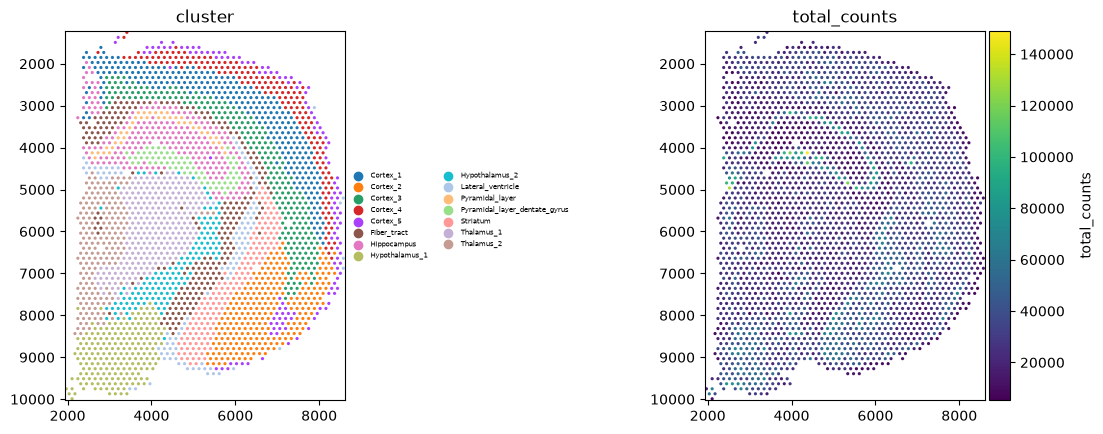

In [10]:
(
    sdata.pl.render_shapes("spots", color=["cluster", "total_counts"])
).pl.show(ncols=2, legend_fontsize=5)

## Summary

- Categorical colours draw a **legend**, continuous colours a **colorbar**, and multichannel images a
  **channel legend** (`channels_as_legend`) — all automatically.
- Place the legend with `legend_loc` (matplotlib locations *or* `"right margin"`), and style it with
  `legend_fontsize`/`fontweight`/`fontoutline`, `legend_title`, `na_in_legend`; or bundle in
  `legend_params`.
- Place and style the colorbar with `colorbar_params`; `loc` (`"right"`/`"left"`/`"top"`/`"bottom"`)
  sets its position and the orientation follows.
- In a multi-panel `color=[...]` figure each panel gets the appropriate key.

## For reproducibility

In [11]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.2
matplotlib      : 3.11.0
numpy           : 2.4.6

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

